# 🎨 Deep Convolutional Generative Adversarial Network (DCGAN)
### Computer Vision Course — Demo Notebook

**Authors:** Dr Dimitris Mousadakos, Dr. Aygul Zagidullina  
**Dataset:** MNIST handwritten digits  
**Framework:** TensorFlow / Keras  
**Runtime:** Google Colab with GPU (T4 recommended ✅)

---

## 🎯 Learning Objectives

By the end of this notebook you will be able to:

1. Explain the **GAN framework** — the adversarial game between Generator and Discriminator
2. Understand the **min-max objective** and why it is non-trivial to optimise
3. Describe the design choices that make **DCGAN** stable (BatchNorm, LeakyReLU, no pooling)
4. Implement separate **loss functions and optimisers** for two competing networks
5. Write a **GAN training loop** using two simultaneous `GradientTape` contexts
6. Diagnose common **GAN failure modes** (mode collapse, training instability)
7. Visualise the **progression of generated images** across training epochs

---

## 📚 Background: Generative Adversarial Networks

### The Core Idea

Proposed by [Goodfellow et al. (2014)](https://arxiv.org/abs/1406.2661), a GAN frames image generation as a **two-player game**:

| Player | Role | Analogy | Goal |
|---|---|---|---|
| **Generator** $G$ | Creates fake images from random noise | Forger / Artist | Fool the discriminator |
| **Discriminator** $D$ | Classifies images as real or fake | Art critic / Detective | Catch the forger |

Both networks are trained **simultaneously** and **adversarially** — each improves by trying to beat the other.

### The Adversarial Game (Min-Max Objective)

The GAN training objective is:

$$\min_G \max_D \; \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

- **Discriminator maximises:** $\log D(x)$ (output 1 for real) + $\log(1-D(G(z)))$ (output 0 for fake)
- **Generator minimises:** $\log(1 - D(G(z)))$, i.e. it wants $D(G(z)) \to 1$ (make fakes look real)

At the **Nash equilibrium**, the generator produces samples indistinguishable from real data,  
and the discriminator outputs $D(x) = 0.5$ for everything (complete uncertainty).

### Training Dynamics

![GAN diagram 1](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gan1.png?raw=1)

![GAN diagram 2](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gan2.png?raw=1)

### What is DCGAN?

[Radford et al. (2015)](https://arxiv.org/pdf/1511.06434.pdf) introduced **Deep Convolutional GAN (DCGAN)** with key architectural guidelines that stabilise GAN training:

| Guideline | Instead of | Reason |
|---|---|---|
| Strided convolutions (no pooling) | Max/avg pooling | Learnable downsampling |
| Batch Normalisation in G and D | No normalisation | Stabilises gradient flow |
| LeakyReLU in D, ReLU in G | Standard ReLU everywhere | Prevents dying neurons in D |
| `tanh` output in G | Sigmoid | Outputs in [-1,1], matching normalised inputs |
| No fully connected hidden layers | Dense layers | Spatial structure preserved |

**Example progression** — images produced by the generator over 50 epochs:

![DCGAN training progression](https://tensorflow.org/images/gan/dcgan.gif)


---
## 🔧 Step 1: Install Dependencies

We need two extra packages:

- **`imageio`**: assembles the per-epoch PNG snapshots into an animated GIF
- **`tensorflow-docs`**: embeds the GIF directly in a Colab output cell


In [ ]:
!pip install -q imageio git+https://github.com/tensorflow/docs
print("✅ Dependencies installed.")


  Preparing metadata (setup.py) ... done
✅ Dependencies installed.


---
## 📦 Step 2: Imports and GPU Check

| Library | Purpose |
|---|---|
| `tensorflow` / `keras.layers` | Build generator and discriminator |
| `numpy` | Numerical operations |
| `matplotlib` | Plotting generated images and loss curves |
| `PIL` | Reading saved PNG files |
| `imageio` / `glob` | Building the training GIF |
| `os` | Checkpoint directory management |
| `time` | Epoch timing |

> ⚡ **Training 50 epochs on CPU takes ~2–3 hours. On a T4 GPU it takes ~5 minutes.**  
> Make sure GPU is enabled: *Runtime → Change runtime type → T4 GPU*


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import time
from IPython import display

# ── GPU check ────────────────────────────────────────────────────────────────
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
    # Allow memory growth — prevents TF from reserving all GPU RAM upfront
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️  No GPU found — enable via Runtime → Change runtime type → T4 GPU")


TensorFlow version: 2.20.0
✅ GPU detected: /physical_device:GPU:0


---
## 📊 Step 3: Load and Preprocess MNIST

### Why normalise to [-1, 1] instead of [0, 1]?

The generator's **output layer uses `tanh`**, which maps to $(-1, +1)$.  
To keep the generated images and real images in the **same numeric range**, we normalise real images to $[-1, 1]$ as well:

$$x_{\text{norm}} = \frac{x - 127.5}{127.5}$$

This is different from the VAE notebook where we normalised to $[0, 1]$ and used `sigmoid` output.  
The choice of output activation and data normalisation must always be consistent.

### Labels are not used

GANs are **unsupervised** — we discard the digit labels entirely.  
The generator learns to produce realistic images without ever knowing which digit is which.

### Batch size = 256

DCGANs use **larger batches** than VAEs because:
- Batch Normalisation in the generator needs a sufficient batch size to estimate stable mean/variance statistics
- Larger batches provide more diverse real/fake samples per gradient step, which stabilises the adversarial game


In [ ]:
# Load MNIST — labels discarded (GAN is unsupervised)
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

print(f"Raw images  shape: {train_images.shape}  |  dtype: {train_images.dtype}")
print(f"Pixel range: [{train_images.min()}, {train_images.max()}]")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Raw images  shape: (60000, 28, 28)  |  dtype: uint8
Pixel range: [0, 255]


In [ ]:
# Reshape: add channel dim → (60000, 28, 28, 1)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')

# Normalise to [-1, 1]  —  must match the generator's tanh output range
train_images = (train_images - 127.5) / 127.5

print(f"Processed images shape: {train_images.shape}")
print(f"Pixel range after normalisation: [{train_images.min():.1f}, {train_images.max():.1f}]")


Processed images shape: (60000, 28, 28, 1)
Pixel range after normalisation: [-1.0, 1.0]


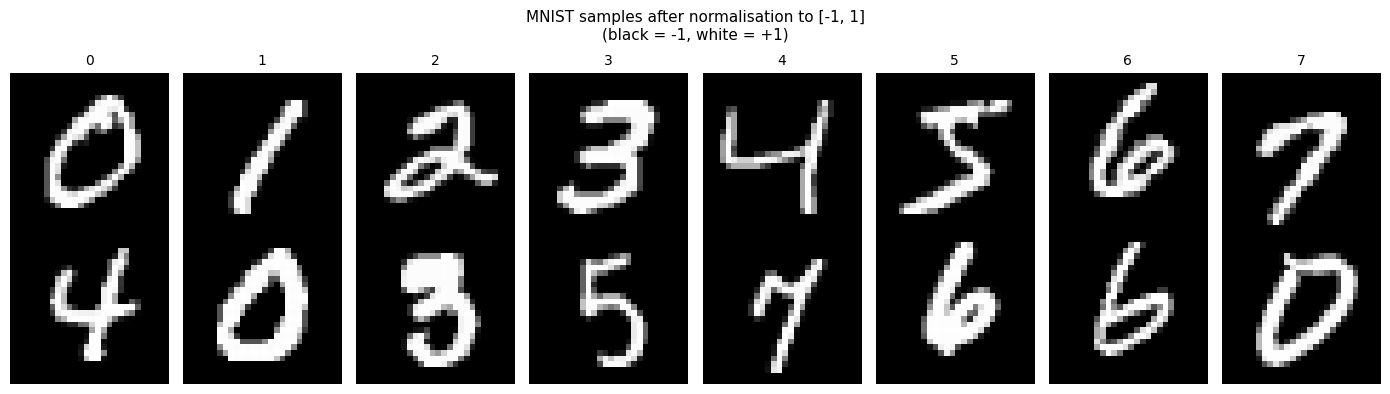

In [ ]:
# Visualise a few samples after normalisation
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('MNIST samples after normalisation to [-1, 1]\n'
             '(black = -1, white = +1)', fontsize=11)

# One example per digit class
for digit in range(8):
    idx = np.where(train_labels == digit)[0][0]
    axes[0, digit].imshow(train_images[idx, :, :, 0], cmap='gray', vmin=-1, vmax=1)
    axes[0, digit].set_title(str(digit), fontsize=10)
    axes[0, digit].axis('off')

# Random samples
for col, idx in enumerate(np.random.choice(len(train_images), 8, replace=False)):
    axes[1, col].imshow(train_images[idx, :, :, 0], cmap='gray', vmin=-1, vmax=1)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('One/class', fontsize=8)
axes[1, 0].set_ylabel('Random', fontsize=8)
plt.tight_layout()
plt.show()


---
## 🔄 Step 4: Build the `tf.data` Pipeline

### Why shuffle?
Each training step feeds a mini-batch of **real images** to the discriminator.  
Without shuffling, the discriminator would see the same sequence of digits every epoch,  
potentially learning spurious order-based patterns rather than true image features.

### Buffer size = 60,000
Setting `shuffle(BUFFER_SIZE)` with `BUFFER_SIZE = 60,000` (= full dataset size) guarantees  
a **perfect uniform shuffle** each epoch. A smaller buffer gives only an approximate shuffle.

### Batch size = 256
This is **8× larger** than the VAE's batch of 32.  
Larger batches are important here because `BatchNormalization` inside the generator needs  
enough samples to compute meaningful running statistics during training.


In [ ]:
BUFFER_SIZE = 60_000   # Full dataset — guarantees uniform shuffle
BATCH_SIZE  = 256      # Large batch needed for stable BatchNorm in generator

train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE)          # Full shuffle each epoch
    .batch(BATCH_SIZE)             # Mini-batches of 256
    .prefetch(tf.data.AUTOTUNE)    # Overlap CPU data prep with GPU training
)

print(f"Batches per epoch: {60_000 // BATCH_SIZE}")

for batch in train_dataset.take(1):
    print(f"Batch shape : {batch.shape}")
    print(f"Pixel range : [{batch.numpy().min():.2f}, {batch.numpy().max():.2f}]")


Batches per epoch: 234
Batch shape : (256, 28, 28, 1)
Pixel range : [-1.00, 1.00]


---
## 🏗️ Step 5: Build the Generator

### Role
The generator $G$ maps a **random noise vector** $z \sim \mathcal{N}(0, I)$  
to a **fake image** $\hat{x} = G(z)$ that should be indistinguishable from real MNIST digits.

### Architecture: noise → image

```
z  (100,)                     ← random noise vector (latent code)
  │
Dense(7×7×256, no bias)       ← project & reshape
BatchNorm → LeakyReLU
Reshape(7, 7, 256)
  │
ConvTranspose(128, 5×5, stride=1, same)   → (7,  7, 128)
BatchNorm → LeakyReLU
  │
ConvTranspose( 64, 5×5, stride=2, same)   → (14, 14, 64)
BatchNorm → LeakyReLU
  │
ConvTranspose(  1, 5×5, stride=2, same, tanh)  → (28, 28,  1)
```

### Key design choices

**`use_bias=False`** in all convolutional layers:  
BatchNormalization adds its own learnable shift ($\beta$), making the bias redundant and slightly wasteful.

**`BatchNormalization()`** after each conv-transpose:  
Normalises activations within each mini-batch → more stable gradients, faster convergence.  
*Not used in the discriminator's input layer or the generator's output layer.*

**`LeakyReLU()`** in the generator:  
Allows a small negative gradient ($\alpha=0.2$ by default) so neurons cannot become permanently inactive.  
More stable than plain ReLU for generators.

**`tanh` output**:  
Maps outputs to $(-1, +1)$, matching our normalised training data range.

**`assert` shape checks**:  
Verify the spatial dimensions at every stage — a cheap safeguard against architecture bugs.


In [ ]:
def make_generator_model():
    """
    DCGAN Generator: random noise z (100,) → fake image (28, 28, 1)

    Uses Conv2DTranspose (learnable upsampling) instead of nearest-neighbour
    or bilinear upsampling — the network learns how to upsample.

    Spatial progression:
      Dense  → Reshape: (7, 7, 256)
      ConvT stride=1  : (7, 7, 128)   ← refine features, no size change
      ConvT stride=2  : (14,14,  64)  ← 2× upsample
      ConvT stride=2  : (28,28,   1)  ← 2× upsample → final image
    """
    model = tf.keras.Sequential(name='Generator')

    # ── Step 1: Project noise vector into a spatial volume ───────────────────
    # Dense output: 7×7×256 = 12,544 values
    # use_bias=False because the following BatchNorm has its own learnable β
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())  # normalise → zero mean, unit var
    model.add(layers.LeakyReLU())           # small negative slope allowed

    # ── Step 2: Reshape flat vector into a 3D spatial volume ─────────────────
    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256), 'Shape mismatch!'

    # ── Step 3: ConvTranspose (stride=1) — refine features, keep 7×7 ─────────
    # stride=1 → no spatial change; this layer mixes features across channels
    model.add(layers.Conv2DTranspose(
        128, kernel_size=(5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # ── Step 4: ConvTranspose (stride=2) — upsample 7×7 → 14×14 ─────────────
    model.add(layers.Conv2DTranspose(
        64, kernel_size=(5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # ── Step 5: ConvTranspose (stride=2) — upsample 14×14 → 28×28 ───────────
    # tanh output: maps to (-1, +1) — must match normalised training data
    # No BatchNorm on the output layer (standard practice)
    model.add(layers.Conv2DTranspose(
        1, kernel_size=(5, 5), strides=(2, 2), padding='same',
        use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model


generator = make_generator_model()
generator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Noise vector shape     : (1, 100)
Generated image shape  : (1, 28, 28, 1)
Pixel value range      : [-0.061, 0.059]


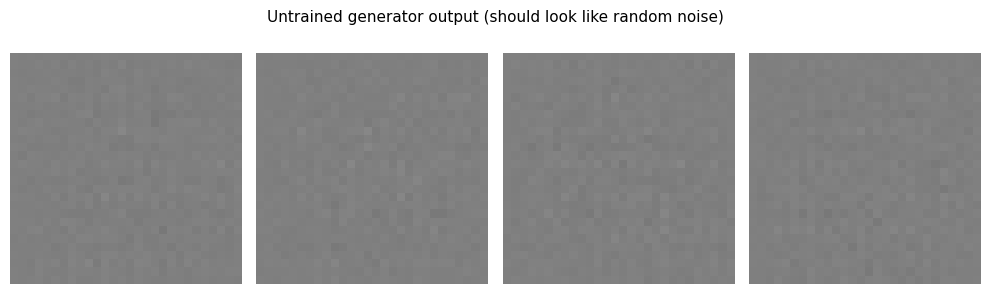

In [ ]:
# ── Test the untrained generator ─────────────────────────────────────────────
# At this stage the generator just maps random noise to random-looking images
tf.random.set_seed(42)
noise = tf.random.normal([1, 100])          # one random 100-dim noise vector
generated_image = generator(noise, training=False)

print(f"Noise vector shape     : {noise.shape}")
print(f"Generated image shape  : {generated_image.shape}")
print(f"Pixel value range      : [{generated_image.numpy().min():.3f}, {generated_image.numpy().max():.3f}]")

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
fig.suptitle('Untrained generator output (should look like random noise)', fontsize=11)
for i, ax in enumerate(axes):
    z = tf.random.normal([1, 100])
    img = generator(z, training=False)
    ax.imshow(img[0, :, :, 0], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
plt.tight_layout()
plt.show()


---
## 🏗️ Step 6: Build the Discriminator

### Role
The discriminator $D$ is a **binary classifier**:  
given an image (real or generated), it outputs a single **logit** (unnormalised score).

- **Positive logit** → model thinks the image is **real**
- **Negative logit** → model thinks the image is **fake**

No sigmoid is applied in the architecture itself — we pass logits directly to the loss function,  
which applies sigmoid internally (numerically more stable).

### Architecture: image → logit

```
x  (28, 28, 1)                ← real or generated image
  │
Conv2D(64,  5×5, stride=2)    → (14, 14, 64)
LeakyReLU → Dropout(0.3)
  │
Conv2D(128, 5×5, stride=2)    → (7,  7,  128)
LeakyReLU → Dropout(0.3)
  │
Flatten → Dense(1)            → scalar logit
```

### Key design choices

**`LeakyReLU(0.2)`** instead of ReLU:  
In the discriminator, a dying ReLU (zero gradient for negative inputs) is especially harmful  
because the discriminator must be able to signal the generator via its gradients.  
LeakyReLU keeps a gradient path open for all inputs.

**`Dropout(0.3)`**:  
Regularises the discriminator so it does not become **too powerful** too quickly.  
If the discriminator is perfect early on, the generator receives no useful gradient signal and training collapses.

**No `BatchNorm` on the input layer**:  
Standard DCGAN practice — applying BatchNorm to the raw input images can distort their statistics.

**No `use_bias=False`**:  
Unlike the generator, the discriminator does not follow every conv with BatchNorm,  
so biases are kept (they are not made redundant).


In [ ]:
def make_discriminator_model():
    """
    DCGAN Discriminator: image (28, 28, 1) → scalar logit

    A standard CNN image classifier with strided convolutions
    (no pooling layers — learnable downsampling as per DCGAN guidelines).

    Outputs a raw logit (no sigmoid) — the loss function applies sigmoid
    internally via BinaryCrossentropy(from_logits=True).

    Spatial progression:
      Input         : (28, 28, 1)
      Conv stride=2 : (14, 14, 64)
      Conv stride=2 : ( 7,  7, 128)
      Flatten       : (7*7*128,) = (6272,)
      Dense(1)      : scalar logit
    """
    model = tf.keras.Sequential(name='Discriminator')

    # ── Block 1: 28×28×1 → 14×14×64 ─────────────────────────────────────────
    # stride=2 halves spatial dimensions (learnable downsampling, no pooling)
    model.add(layers.Conv2D(
        64, kernel_size=(5, 5), strides=(2, 2), padding='same',
        input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())   # negative slope keeps gradients flowing
    model.add(layers.Dropout(0.3))  # regularise so D doesn't overpower G early

    # ── Block 2: 14×14×64 → 7×7×128 ─────────────────────────────────────────
    model.add(layers.Conv2D(
        128, kernel_size=(5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # ── Output: flatten and classify ─────────────────────────────────────────
    model.add(layers.Flatten())     # 7×7×128 = 6272 features
    model.add(layers.Dense(1))      # single logit output (no sigmoid!)

    return model


discriminator = make_discriminator_model()
discriminator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Test the untrained discriminator ─────────────────────────────────────────
# Before training: outputs are essentially random
decision_real = discriminator(train_images[:4], training=False)
decision_fake = discriminator(generator(tf.random.normal([4, 100]), training=False), training=False)

print("Discriminator output on real images (logits — positive = real):")
print(decision_real.numpy().flatten())
print("\nDiscriminator output on fake images (logits — negative = fake):")
print(decision_fake.numpy().flatten())
print("\n(Before training these are essentially random — near zero)")


Discriminator output on real images (logits — positive = real):
[0.2132089  0.2745368  0.24767718 0.27781588]

Discriminator output on fake images (logits — negative = fake):
[-0.00025713  0.00734609  0.0033229   0.0029471 ]

(Before training these are essentially random — near zero)


---
## 📐 Step 7: Loss Functions

### Binary Cross-Entropy from Logits

Both losses are based on **binary cross-entropy**:  
$\mathcal{L} = -[y \log \sigma(\hat{y}) + (1-y)\log(1 - \sigma(\hat{y}))]$

We use `BinaryCrossentropy(from_logits=True)`, which applies sigmoid internally.  
This is **numerically safer** than applying sigmoid ourselves and then computing log.

---

### Discriminator Loss

The discriminator has **two objectives**:

1. **Classify real images as real:** compare $D(x_{\text{real}})$ against **1** (real label)
2. **Classify fake images as fake:** compare $D(G(z))$ against **0** (fake label)

$$\mathcal{L}_D = \underbrace{\text{BCE}(D(x),\, 1)}_{\text{real loss}} + \underbrace{\text{BCE}(D(G(z)),\, 0)}_{\text{fake loss}}$$

A well-trained discriminator should have: $D(x) \approx 1$ and $D(G(z)) \approx 0$.

---

### Generator Loss

The generator wants to **fool** the discriminator — it wants $D(G(z))$ to be classified as real:

$$\mathcal{L}_G = \text{BCE}(D(G(z)),\, 1)$$

The generator is only judged on how the discriminator reacts to **fake images**.  
It never sees real images directly.

---

### Separate Optimisers

Each network has its **own Adam optimiser** because:
- They are updated **alternately** in each training step
- They may need different learning rate schedules
- Gradients for $G$ and $D$ must not interfere with each other

Both use `lr=1e-4`, which is standard for DCGAN on MNIST.


In [ ]:
# Shared loss function — binary cross-entropy, applied to logits
# from_logits=True: expects raw logits (no sigmoid applied beforehand)
# This is numerically more stable than sigmoid → BCE separately
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


def discriminator_loss(real_output, fake_output):
    """
    Discriminator loss = real_loss + fake_loss

    real_loss: D should output ≈ 1 for real images  → compare to ones
    fake_loss: D should output ≈ 0 for fake images  → compare to zeros

    Args:
        real_output : D(x_real),  shape (batch, 1), logits
        fake_output : D(G(z)),    shape (batch, 1), logits
    Returns:
        Scalar loss value
    """
    real_loss  = cross_entropy(tf.ones_like(real_output),  real_output)  # target = 1
    fake_loss  = cross_entropy(tf.zeros_like(fake_output), fake_output)  # target = 0
    return real_loss + fake_loss


def generator_loss(fake_output):
    """
    Generator loss: G wants D to classify its fakes as real → target = 1

    If the generator fools the discriminator perfectly, D(G(z)) ≈ 1
    and this loss → 0.

    Args:
        fake_output : D(G(z)),  shape (batch, 1), logits
    Returns:
        Scalar loss value
    """
    return cross_entropy(tf.ones_like(fake_output), fake_output)  # target = 1


# ── Separate optimisers for each network ─────────────────────────────────────
# They must be separate because gradient updates are applied independently
generator_optimizer     = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

print("Loss functions and optimisers defined.")
print(f"Generator optimizer    : Adam(lr=1e-4)")
print(f"Discriminator optimizer: Adam(lr=1e-4)")


Loss functions and optimisers defined.
Generator optimizer    : Adam(lr=1e-4)
Discriminator optimizer: Adam(lr=1e-4)


---
## 💾 Step 8: Checkpointing

Training a GAN for 50 epochs can take several minutes.  
**Checkpoints** save the model weights to disk every 15 epochs so that:

- If Colab disconnects, you can **resume** from the last saved state
- You can **compare** generator quality at different training stages
- You can **revert** if training diverges after a good checkpoint

The checkpoint saves both networks **and** their optimiser states  
(so Adam's momentum buffers are preserved — important for resuming correctly).


In [ ]:
checkpoint_dir    = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')

# Save generator, discriminator AND their optimiser states
# Saving optimiser state is crucial: Adam has momentum buffers that must
# be restored to resume training from the exact same point.
checkpoint = tf.train.Checkpoint(
    generator_optimizer     = generator_optimizer,
    discriminator_optimizer = discriminator_optimizer,
    generator               = generator,
    discriminator           = discriminator
)

os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoints will be saved to: {checkpoint_dir}")
print("Saved every 15 epochs during training.")


Checkpoints will be saved to: ./training_checkpoints
Saved every 15 epochs during training.


---
## 🏋️ Step 9: The Training Loop

### The GAN training schema

![GAN Training schema](https://github.com/toelt-llc/ADL-Book-2nd-Ed/blob/master/docs/GAN/images/GAN_Training_Schema.png?raw=1)

Each training step alternates between two phases:

**Phase A — Update the Discriminator:**
1. Sample real images $x$ from the dataset
2. Sample noise $z \sim \mathcal{N}(0,I)$, generate fake images $\hat{x} = G(z)$
3. Compute $\mathcal{L}_D$ = loss on real + loss on fake
4. Compute $\nabla_D \mathcal{L}_D$ and update **discriminator weights only**

**Phase B — Update the Generator:**
1. Sample noise $z$, generate $\hat{x} = G(z)$ *(using the freshly updated D)*
2. Compute $\mathcal{L}_G$ = how convincingly D classifies $\hat{x}$ as real
3. Compute $\nabla_G \mathcal{L}_G$ and update **generator weights only**

### Two simultaneous `GradientTape` contexts

TensorFlow's `GradientTape` records operations for automatic differentiation.  
We open **two tapes simultaneously** — one for each network —  
so that we can compute gradients for both from a single forward pass.

```python
with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    ...  # forward pass recorded by both tapes
gen_grads  = gen_tape.gradient(gen_loss,  generator.trainable_variables)
disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
```

### `training=True` vs `training=False`

| Setting | Effect on BatchNorm | Effect on Dropout |
|---|---|---|
| `training=True` | Uses batch statistics (mean/var from current batch) | Randomly drops neurons |
| `training=False` | Uses running statistics (accumulated across all batches) | No dropout |

During training we use `training=True` so BatchNorm and Dropout behave correctly.  
During image generation (for visualisation), we use `training=False`.

### `@tf.function` — graph compilation

`@tf.function` compiles the Python function into a TensorFlow computation graph.  
This avoids Python overhead on every call and enables XLA optimisations on GPU,  
typically giving a **2–5× speedup** over eager execution.


In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS      = 50     # Standard for DCGAN on MNIST; ~5 min on T4 GPU
NOISE_DIM   = 100    # Dimensionality of the latent noise vector z
NUM_EXAMPLES = 16    # Images to generate per epoch (shown in 4×4 grid)

# Fixed seed — reused every epoch so we can track the SAME noise vectors
# and see how the generator improves at turning them into recognisable digits
tf.random.set_seed(0)
seed = tf.random.normal([NUM_EXAMPLES, NOISE_DIM])

print(f"Training for {EPOCHS} epochs")
print(f"Noise vector dimension: {NOISE_DIM}")
print(f"Fixed seed shape: {seed.shape}")


Training for 50 epochs
Noise vector dimension: 100
Fixed seed shape: (16, 100)


In [ ]:
@tf.function   # Compile to TF graph — critical for GPU speed
def train_step(images):
    """
    Single GAN training step — updates both G and D from one mini-batch.

    Args:
        images : mini-batch of real images, shape (BATCH_SIZE, 28, 28, 1)

    Two-phase update (A then B):
      A: Discriminator update — learn to tell real from fake
      B: Generator update     — learn to fool the discriminator

    Both phases share the same forward pass (same noise, same generated images)
    via simultaneous GradientTape contexts.
    """
    # Sample fresh noise for this step
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    # ── Forward pass — recorded by BOTH tapes simultaneously ─────────────────
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generator creates fake images from noise
        # training=True: BatchNorm uses batch statistics, Dropout active
        generated_images = generator(noise, training=True)

        # Discriminator scores both real and fake images
        real_output = discriminator(images,           training=True)
        fake_output = discriminator(generated_images, training=True)

        # Compute losses for each network
        gen_loss  = generator_loss(fake_output)               # G wants D(G(z)) → 1
        disc_loss = discriminator_loss(real_output, fake_output)  # D: real→1, fake→0

    # ── Phase A: Update Discriminator ────────────────────────────────────────
    # Gradients of disc_loss w.r.t. DISCRIMINATOR weights only
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(
        zip(disc_grads, discriminator.trainable_variables))

    # ── Phase B: Update Generator ─────────────────────────────────────────────
    # Gradients of gen_loss w.r.t. GENERATOR weights only
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(
        zip(gen_grads, generator.trainable_variables))

    return gen_loss, disc_loss   # return for logging


In [ ]:
def generate_and_save_images(model, epoch, test_input, save=True):
    """
    Generate a 4×4 grid of images using the fixed seed vector.

    Important: training=False disables Dropout and makes BatchNorm
    use running statistics (not current-batch statistics).
    This gives stable, deterministic output for comparison across epochs.

    Pixel values from tanh are in (-1, 1) — we rescale to [0, 255]
    for display:  pixel_display = pixel * 127.5 + 127.5
    """
    # Inference mode: no Dropout, BatchNorm uses running stats
    predictions = model(test_input, training=False)

    fig, axes = plt.subplots(4, 4, figsize=(5, 5))
    title = 'Before training' if epoch == 0 else f'Epoch {epoch:02d}'
    fig.suptitle(f'{title} — Generated images', fontsize=11, y=1.01)

    for i, ax in enumerate(axes.flat):
        # Rescale from tanh range (-1,1) → display range [0, 255]
        img = predictions[i, :, :, 0] * 127.5 + 127.5
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')

    plt.tight_layout()
    if save:
        plt.savefig(f'image_at_epoch_{epoch:04d}.png', bbox_inches='tight', dpi=80)
    plt.show()
    plt.close(fig)


def train(dataset, epochs):
    """
    Full DCGAN training loop.

    For each epoch:
      1. Iterate over all mini-batches → run train_step
      2. Log average losses for the epoch
      3. Generate and save a 4×4 image grid from the fixed seed
      4. Save checkpoint every 15 epochs
      5. Print timing info

    Loss tracking:
      gen_loss  should decrease over time (generator improves)
      disc_loss should stay near log(2) ≈ 0.693 at Nash equilibrium
    """
    gen_loss_history  = []
    disc_loss_history = []

    for epoch in range(epochs):
        start = time.time()
        epoch_gen_loss  = tf.keras.metrics.Mean()
        epoch_disc_loss = tf.keras.metrics.Mean()

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_gen_loss(g_loss)
            epoch_disc_loss(d_loss)

        g = epoch_gen_loss.result().numpy()
        d = epoch_disc_loss.result().numpy()
        gen_loss_history.append(g)
        disc_loss_history.append(d)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)
            print(f"  ✅ Checkpoint saved at epoch {epoch + 1}")

        print(f'Epoch {epoch+1:02d}/{epochs}  |  Gen loss: {g:.4f}  |  Disc loss: {d:.4f}  |  Time: {time.time()-start:.1f}s')

    # Final generation
    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

    return gen_loss_history, disc_loss_history


---
## 🚀 Step 10: Run Training

Show the initial (untrained) generator output, then train for 50 epochs.

> ⏱️ **Expected time on T4 GPU:** ~5–8 minutes total (6–10 seconds per epoch)

> 💡 **What to watch for:**
> - Epochs 1–5: pure noise
> - Epochs 10–20: blurry digit-like blobs appear
> - Epochs 30–50: recognisable MNIST-style digits


Generator output BEFORE training:


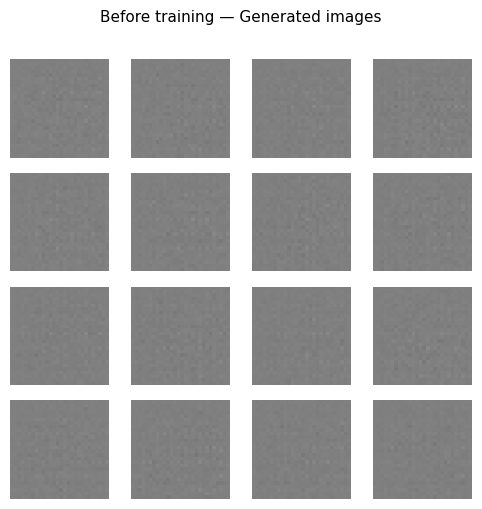

In [ ]:
print("Generator output BEFORE training:")
generate_and_save_images(generator, 0, seed, save=True)


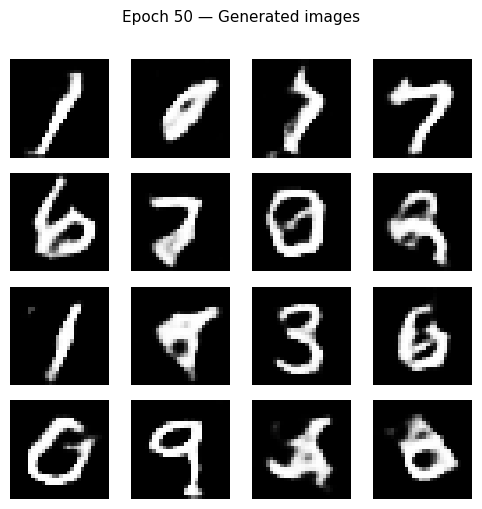


✅ Training complete!


In [ ]:
print("Starting DCGAN training...")
print("=" * 60)
gen_losses, disc_losses = train(train_dataset, EPOCHS)
print("\n✅ Training complete!")


---
## 📈 Step 11: Loss Curves and Training Diagnostics

### Interpreting GAN loss curves

GAN losses are **not monotonically decreasing** like standard classification losses.  
This is expected — the two networks are competing, so they oscillate.

| Signal | Interpretation |
|---|---|
| Disc loss ≈ 0 | Discriminator is perfect — generator gets no gradient signal |
| Disc loss ≈ ln(2) ≈ 0.693 | Nash equilibrium — D is at 50/50 uncertainty |
| Gen loss decreasing | Generator is improving at fooling D |
| Disc loss → 0 rapidly | **Mode collapse risk** — G may be stuck on a few images |
| Both losses exploding | Training instability — try lower learning rate |


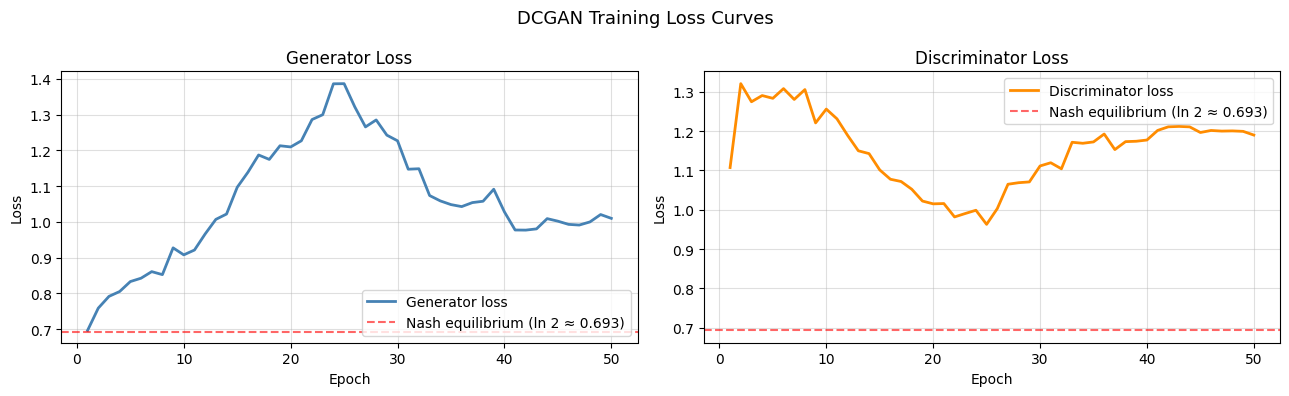

Final Generator loss    : 1.0097
Final Discriminator loss: 1.1899
Nash equilibrium target : 0.6931  (ln 2)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, gen_losses,  color='steelblue', linewidth=2, label='Generator loss')
ax1.axhline(y=0.693, color='red', linestyle='--', alpha=0.6,
            label='Nash equilibrium (ln 2 ≈ 0.693)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Generator Loss')
ax1.legend(); ax1.grid(True, alpha=0.4)

ax2.plot(epochs_range, disc_losses, color='darkorange', linewidth=2, label='Discriminator loss')
ax2.axhline(y=0.693, color='red', linestyle='--', alpha=0.6,
            label='Nash equilibrium (ln 2 ≈ 0.693)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Discriminator Loss')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle('DCGAN Training Loss Curves', fontsize=13)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"Final Generator loss    : {gen_losses[-1]:.4f}")
print(f"Final Discriminator loss: {disc_losses[-1]:.4f}")
print(f"Nash equilibrium target : 0.6931  (ln 2)")


---
## 🎨 Step 12: Visualisations

### 12.1 Final generated images


Restored checkpoint from: ./training_checkpoints


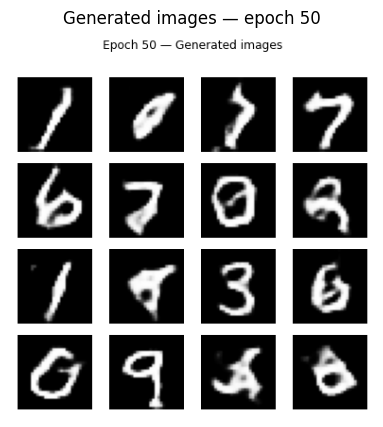

In [ ]:
# Restore from the latest checkpoint (in case of any interruption)
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))
print(f"Restored checkpoint from: {checkpoint_dir}")

plt.figure(figsize=(5, 5))
plt.imshow(PIL.Image.open(f'image_at_epoch_{EPOCHS:04d}.png'))
plt.axis('off')
plt.title(f"Generated images — epoch {EPOCHS}", fontsize=12)
plt.show()


### 12.2 Animated GIF — training progression


/tmp/ipykernel_12540/2526018883.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(filename))
/tmp/ipykernel_12540/2526018883.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(filenames[-1]))


GIF saved: dcgan.gif  (51 frames)



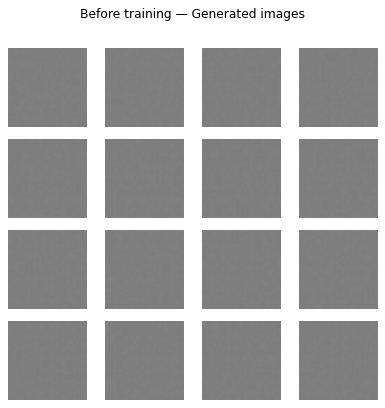

In [ ]:
anim_file = 'dcgan.gif'

filenames = sorted(glob.glob('image_at_epoch_*.png'))
with imageio.get_writer(anim_file, mode='I', duration=0.3) as writer:
    for filename in filenames:
        writer.append_data(imageio.imread(filename))
    # Hold the last frame
    for _ in range(5):
        writer.append_data(imageio.imread(filenames[-1]))

print(f"GIF saved: {anim_file}  ({len(filenames)} frames)")

import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)


### 12.3 Side-by-side: Real vs Generated

A direct comparison lets us visually assess generation quality.


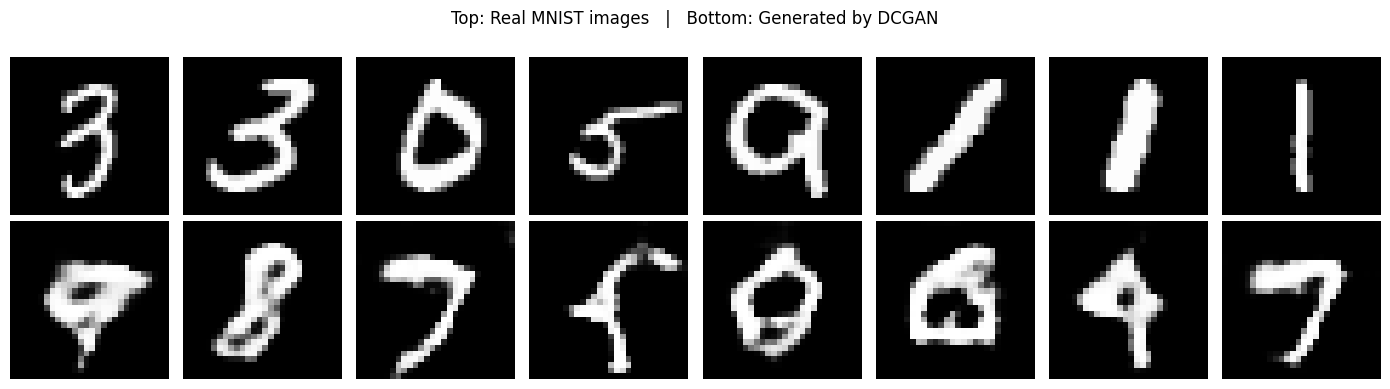

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Top: Real MNIST images   |   Bottom: Generated by DCGAN', fontsize=12)

# Real images (from training set)
real_idx = np.random.choice(len(train_images), 8, replace=False)
for col, idx in enumerate(real_idx):
    axes[0, col].imshow(train_images[idx, :, :, 0], cmap='gray', vmin=-1, vmax=1)
    axes[0, col].axis('off')

# Generated images
gen_imgs = generator(tf.random.normal([8, NOISE_DIM]), training=False).numpy()
for col in range(8):
    axes[1, col].imshow(gen_imgs[col, :, :, 0], cmap='gray', vmin=-1, vmax=1)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Real', fontsize=10, color='green')
axes[1, 0].set_ylabel('Generated', fontsize=10, color='red')
plt.tight_layout()
plt.show()


### 12.4 Large Generation Grid

Generate a 10×10 grid of novel images — each from a different random noise vector.


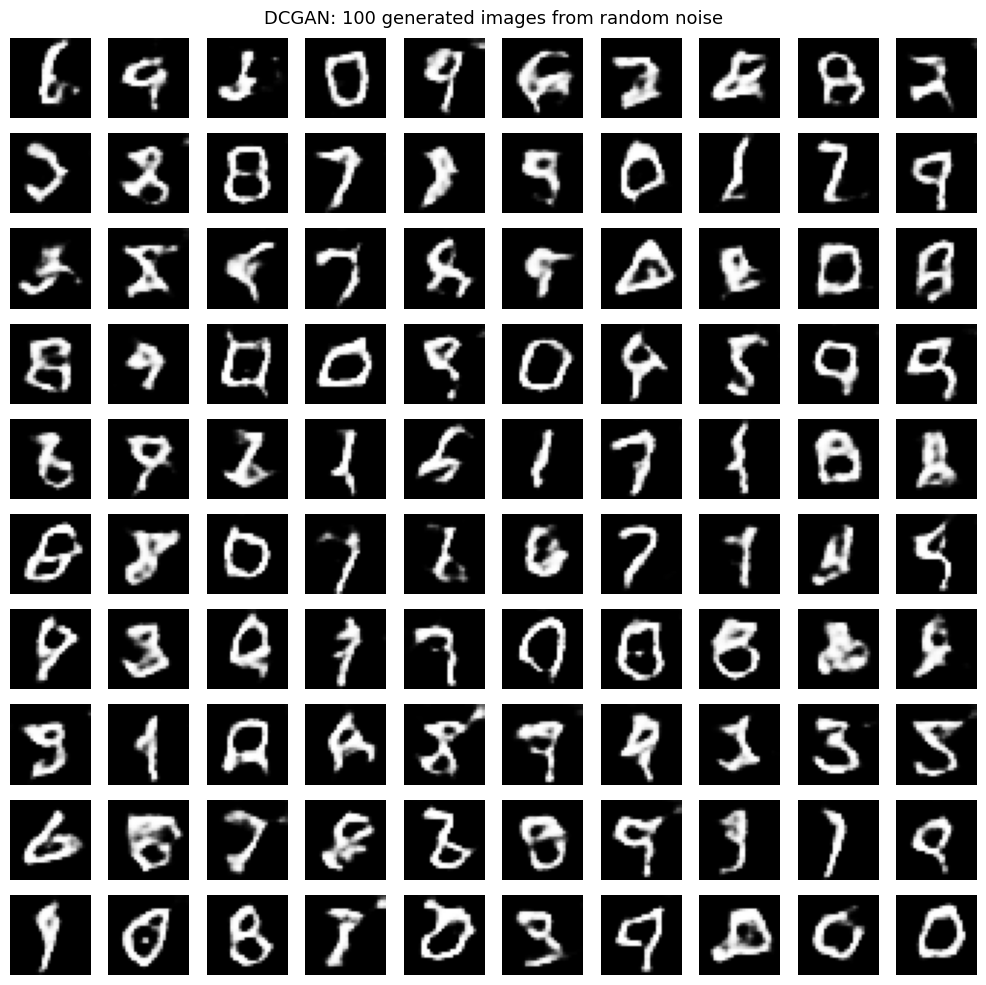

In [ ]:
tf.random.set_seed(99)
n = 10
z_grid = tf.random.normal([n * n, NOISE_DIM])
imgs   = generator(z_grid, training=False).numpy()

fig, axes = plt.subplots(n, n, figsize=(10, 10))
fig.suptitle(f'DCGAN: {n*n} generated images from random noise', fontsize=13)
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i, :, :, 0], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
plt.tight_layout()
plt.show()


### 12.5 Noise Vector Interpolation

We can smoothly interpolate between two noise vectors $z_A$ and $z_B$:  
$z(\alpha) = (1-\alpha) \cdot z_A + \alpha \cdot z_B, \quad \alpha \in [0, 1]$

A smooth transition in image space indicates the generator has learned a **continuous latent manifold**,  
rather than memorising training examples.


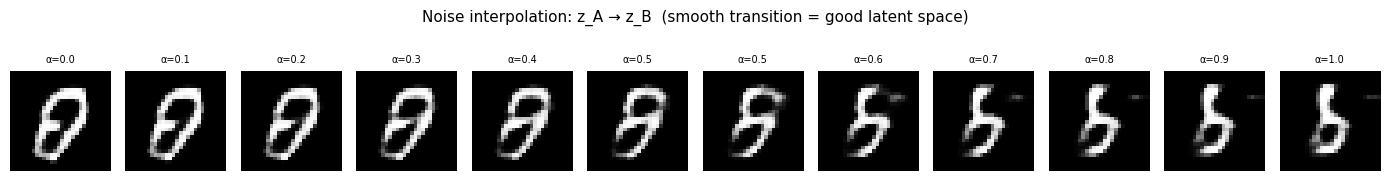

In [ ]:
def interpolate_noise(generator, steps=10):
    """Interpolate between two random noise vectors and decode each step."""
    tf.random.set_seed(7)
    z_a = tf.random.normal([1, NOISE_DIM])
    z_b = tf.random.normal([1, NOISE_DIM])

    alphas   = np.linspace(0, 1, steps)
    z_interp = tf.constant(
        np.array([(1 - a) * z_a.numpy() + a * z_b.numpy() for a in alphas])[:, 0, :],
        dtype=tf.float32)          # shape: (steps, NOISE_DIM)

    imgs = generator(z_interp, training=False).numpy()  # (steps, 28, 28, 1)

    fig, axes = plt.subplots(1, steps, figsize=(14, 2))
    fig.suptitle('Noise interpolation: z_A → z_B  (smooth transition = good latent space)',
                 fontsize=11)
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i, :, :, 0], cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'α={alphas[i]:.1f}', fontsize=7)
        ax.axis('off')
    plt.tight_layout()
plt.show()


interpolate_noise(generator, steps=12)


---
## ⚠️ Step 13: GAN Failure Modes — What Can Go Wrong?

Training GANs is notoriously tricky. Understanding failure modes is essential.

### Mode Collapse

The generator learns to produce only **a few types** of images (e.g., always the digit '1')  
because they reliably fool the discriminator. It ignores most of the data distribution.

**Detection:** Generated images all look very similar; discriminator loss → 0.

**Mitigation strategies:**
- **Minibatch discrimination**: Feed features from multiple images to D simultaneously
- **Unrolled GANs**: Optimise G against future discriminator states
- **Wasserstein GAN (WGAN)**: Replace cross-entropy with Wasserstein distance

### Vanishing Gradients

If the discriminator becomes **too good too fast**, the gradient signal back to the generator  
becomes effectively zero — the generator has no direction to improve.

**Mitigation:** Use Dropout in D, balance learning rates, label smoothing.

### Training Instability (Oscillation)

Neither network converges — losses oscillate wildly instead of stabilising.

**Mitigation:** Lower learning rates, spectral normalisation, gradient penalty (WGAN-GP).

### Quick diversity check


Generated image diversity check (100 samples):
  Mean pixel std across samples: 0.3625
  (Higher = more diverse; values near 0 suggest mode collapse)


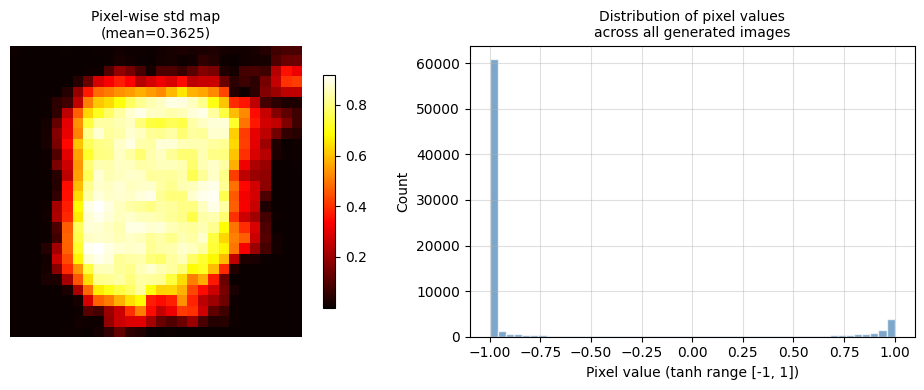

In [ ]:
def check_diversity(generator, noise_dim, n_samples=100):
    """Check for mode collapse by measuring variance across many generated images."""
    tf.random.set_seed(123)
    z = tf.random.normal([n_samples, noise_dim])
    imgs = generator(z, training=False).numpy()   # (100, 28, 28, 1)

    # Pixel-wise standard deviation across all generated images
    pixel_std = imgs.std(axis=0)                  # (28, 28, 1)
    mean_std  = pixel_std.mean()

    print(f"Generated image diversity check ({n_samples} samples):")
    print(f"  Mean pixel std across samples: {mean_std:.4f}")
    print(f"  (Higher = more diverse; values near 0 suggest mode collapse)")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Show pixel-wise standard deviation map
    axes[0].imshow(pixel_std[:, :, 0], cmap='hot')
    axes[0].set_title(f'Pixel-wise std map\n(mean={mean_std:.4f})', fontsize=10)
    axes[0].axis('off')
    plt.colorbar(axes[0].images[0], ax=axes[0], shrink=0.8)

    # Histogram of all pixel values across generated images
    axes[1].hist(imgs.flatten(), bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    axes[1].set_xlabel('Pixel value (tanh range [-1, 1])')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of pixel values\nacross all generated images', fontsize=10)
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
plt.show()


check_diversity(generator, NOISE_DIM)


---
## 🔍 Step 14: VAE vs GAN — Conceptual Comparison

| Aspect | VAE | GAN |
|---|---|---|
| **Training objective** | Maximise ELBO (reconstruction + KL) | Min-max adversarial game |
| **Latent space** | Structured, continuous ($\mathcal{N}(0,I)$ prior enforced) | Unstructured noise vector |
| **Image quality** | Blurrier (optimises pixel-level reconstruction) | Sharper (adversarial sharpness) |
| **Training stability** | Stable (single loss, smooth gradient) | Notoriously unstable |
| **Mode coverage** | Tends to average modes (blurry) | Risk of mode collapse |
| **Latent interpolation** | Smooth, semantically meaningful | Smooth, but less interpretable |
| **Evaluation metrics** | ELBO, reconstruction loss | FID, Inception Score, IS |
| **Requires labels?** | No | No |
| **Best for** | Structured generation, compression, anomaly detection | High-quality realistic image synthesis |

> **Modern practice:** GANs and VAEs are often **combined** (e.g., VAE-GAN) or superseded  
> by **Diffusion Models**, which are currently state-of-the-art for image generation.


---
## 📝 Exercises

---

### 🟢 Exercise 1 — Noise Dimension Sensitivity *(Easy)*

The noise vector $z$ has `NOISE_DIM = 100` dimensions by default.

**Task:** Retrain the DCGAN with `NOISE_DIM = 10` and again with `NOISE_DIM = 256`.  
(Use 20–30 epochs for speed.)

Answer:
1. Does image quality visually change?
2. Does the generator lose diversity (mode collapse) with a smaller noise dim?
3. How does training time change with noise dim?

*Hint: Only the first `Dense` layer of the generator and the seed vector depend on `NOISE_DIM`.*


In [ ]:
# ── Exercise 1: Your code here ───────────────────────────────────────────────

def build_and_train_dcgan(noise_dim, epochs=25, batch_size=256):
    """
    Helper: build a fresh DCGAN with given noise_dim, train, return losses.
    Adjust the generator's Dense layer input shape to noise_dim.
    """
    # TODO: Define make_generator_model_nd(noise_dim) that takes noise_dim
    #       as a parameter (change input_shape=(noise_dim,) and Dense size).
    # TODO: Define make_discriminator_model() (same as before).
    # TODO: Define losses and optimisers.
    # TODO: Train for `epochs` epochs, return gen_losses, disc_losses.
    pass


# Uncomment and complete to run:
# gen_losses_10,  disc_losses_10  = build_and_train_dcgan(noise_dim=10,  epochs=25)
# gen_losses_256, disc_losses_256 = build_and_train_dcgan(noise_dim=256, epochs=25)

# Compare loss curves and generated image grids for each noise_dim
# TODO: Plot comparison


---

### 🟡 Exercise 2 — Label Smoothing *(Medium)*

**Label smoothing** is a regularisation technique that replaces hard targets  
(`0` and `1`) with soft targets (`0.1` and `0.9`).

Intuition: prevents the discriminator from becoming **over-confident**,  
which in turn provides more informative gradient signals back to the generator.

**Task:** Modify the `discriminator_loss` function to use **one-sided label smoothing**:  
- Real label: `0.9` instead of `1.0` (smooth real labels only)
- Fake label: keep `0.0` (no smoothing on fake)

Retrain and compare:
1. Do the loss curves look more stable?
2. Does visual image quality improve?
3. Why do we smooth **only** the real labels (one-sided)?

*Bonus: Try two-sided smoothing (both 0.9 and 0.1) and compare.*


In [ ]:
# ── Exercise 2: Your code here ───────────────────────────────────────────────

def discriminator_loss_smoothed(real_output, fake_output, real_label=0.9, fake_label=0.0):
    """
    Discriminator loss with one-sided label smoothing.

    One-sided: only smooth real labels (1.0 → real_label=0.9)
    Why one-sided? Smoothing fake labels (0 → 0.1) would tell the generator
    that it's OK to produce 10% fake-like images — not desirable.

    Args:
        real_output : D(x_real), logits
        fake_output : D(G(z)),   logits
        real_label  : soft label for real images (default 0.9)
        fake_label  : label for fake images (default 0.0)
    """
    # TODO: Replace tf.ones_like with real_label * tf.ones_like(...)
    # TODO: Replace tf.zeros_like with fake_label * tf.ones_like(...)
    real_loss = cross_entropy(tf.ones_like(real_output),  real_output)  # ← MODIFY
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)  # ← MODIFY
    return real_loss + fake_loss


# TODO: Retrain using discriminator_loss_smoothed instead of discriminator_loss
# TODO: Compare loss curves and generated images with and without smoothing


---

### 🔴 Exercise 3 — Conditional DCGAN (cDCGAN) *(Hard)*

A **conditional GAN** (cGAN, [Mirza & Osindero 2014](https://arxiv.org/abs/1411.1784))  
extends the standard GAN by conditioning both $G$ and $D$ on a class label $y$.

This allows us to **control which digit** the generator produces:

$$G(z, y) \to \hat{x}_y, \quad D(x, y) \to \text{logit}$$

**Implementation strategy:**

1. **Embedding**: Map the integer label $y \in \{0,\ldots,9\}$ to a dense embedding vector
2. **Generator**: Concatenate the embedding with the noise vector before the Dense layer
3. **Discriminator**: Concatenate the embedding with the flattened feature map before Dense(1)

**Task:**
1. Implement `make_conditional_generator(noise_dim, num_classes=10)`
2. Implement `make_conditional_discriminator(num_classes=10)`
3. Modify `train_step` to also sample and pass labels
4. Train for 30 epochs and verify you can generate specific digits on demand


In [ ]:
# ── Exercise 3: Conditional DCGAN skeleton ───────────────────────────────────

def make_conditional_generator(noise_dim=100, num_classes=10, embed_dim=50):
    """
    Conditional Generator: (z, y) → image

    Strategy:
      1. Embed label y: Embedding(num_classes, embed_dim) → (embed_dim,)
      2. Concatenate with z: (noise_dim + embed_dim,)
      3. Rest of architecture same as standard generator

    Uses Keras Functional API instead of Sequential for multi-input.
    """
    # Noise input
    noise_input = tf.keras.Input(shape=(noise_dim,), name='noise')

    # Label input
    label_input = tf.keras.Input(shape=(1,), dtype='int32', name='label')

    # Embed the label
    # TODO: Add Embedding layer: Embedding(num_classes, embed_dim)(label_input)
    # TODO: Flatten the embedding
    # TODO: Concatenate noise + embedding
    # TODO: Apply Dense(7*7*256) + BatchNorm + LeakyReLU
    # TODO: Reshape and add Conv2DTranspose layers as before

    pass


def make_conditional_discriminator(num_classes=10, embed_dim=50):
    """
    Conditional Discriminator: (x, y) → logit

    Strategy:
      1. Process image with Conv layers as before
      2. Embed label y
      3. Concatenate flattened features + embedding
      4. Dense(1) → logit
    """
    # Image input
    image_input = tf.keras.Input(shape=(28, 28, 1), name='image')

    # Label input
    label_input = tf.keras.Input(shape=(1,), dtype='int32', name='label')

    # TODO: Apply Conv2D layers to image_input (same as discriminator before)
    # TODO: Flatten image features
    # TODO: Embed and flatten label
    # TODO: Concatenate image features + label embedding
    # TODO: Dense(1) → logit output

    pass


# After implementing the models, test with:
# cgen  = make_conditional_generator()
# cdisc = make_conditional_discriminator()
#
# Test generation of specific digits:
# z = tf.random.normal([10, 100])
# labels = tf.constant([[d] for d in range(10)], dtype='int32')
# imgs = cgen([z, labels], training=False)
# Show one image per class


---
## 🏁 Summary & Key Takeaways

| Concept | What we learned |
|---|---|
| **GAN framework** | Two-player adversarial game: G fools D, D catches G; equilibrium = G matches data distribution |
| **Min-max objective** | $\min_G \max_D$: not a standard loss — no single quantity monotonically decreases |
| **DCGAN guidelines** | Strided convolutions, BatchNorm, LeakyReLU, tanh output, no pooling |
| **Dual GradientTape** | Two simultaneous tapes allow separate G and D gradient computation from one forward pass |
| **`training=True/False`** | Critical for BatchNorm (batch vs running stats) and Dropout (active vs off) |
| **Loss interpretation** | Disc loss ≈ ln(2) at equilibrium; Gen loss should decrease; both oscillate normally |
| **Mode collapse** | G produces few images; detected via low pixel-wise variance across samples |
| **GAN vs VAE** | GANs = sharper images but unstable; VAEs = stable but blurrier; Diffusion = current SOTA |

---

### 📖 Further Reading

- **Original GAN:** [Goodfellow et al. (2014)](https://arxiv.org/abs/1406.2661)
- **DCGAN:** [Radford et al. (2015)](https://arxiv.org/pdf/1511.06434.pdf)
- **Conditional GAN:** [Mirza & Osindero (2014)](https://arxiv.org/abs/1411.1784)
- **Wasserstein GAN:** [Arjovsky et al. (2017)](https://arxiv.org/abs/1701.07875)
- **StyleGAN2:** [Karras et al. (2020)](https://arxiv.org/abs/1912.04958)
- **TF official DCGAN tutorial:** https://www.tensorflow.org/tutorials/generative/dcgan
